# Session 2: Python Foundations for Research

**Workshop:** Undergraduate Research Computing Bootcamp

> Open this notebook in Google Colab and run each code cell in order.

## Learning objectives

- Use variables, functions, lists, and dictionaries
- Load and analyze tabular data
- Create simple plots for scientific interpretation

## How to use this notebook

1. Read each short explanation.
2. Run each code cell.
3. Complete the exercises marked **Your turn**.
4. Save a copy of the notebook to your Google Drive or GitHub.

## Python as a research tool

Python is widely used in research because it is readable, flexible, and has a large ecosystem of scientific libraries.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Functions

Functions let us reuse analysis steps and reduce mistakes.

In [8]:
def compute_mean_and_std(values):
    values = np.asarray(values)
    return values.mean(), values.std()

measurements = [1.2, 1.5, 1.4, 1.8, 1.7]
mean_value, std_value = compute_mean_and_std(measurements)

print("Mean:", mean_value)
print("Standard deviation:", std_value)

Mean: 1.52
Standard deviation: 0.21354156504062627


## Create a small dataset

The next cell creates a small table that mimics experimental or simulation outputs.

In [9]:
data = pd.DataFrame({
    "case_id": ["case_01", "case_02", "case_03", "case_04"],
    "pressure_drop": [8.2, 12.5, 6.9, 15.1],
    "flow_rate": [1.1, 1.3, 0.9, 1.5],
})

data

,case_id,pressure_drop,flow_rate
0,case_01,8.2,1.1
1,case_02,12.5,1.3
2,case_03,6.9,0.9
3,case_04,15.1,1.5


In [10]:
data["resistance_index"] = data["pressure_drop"] / data["flow_rate"]
data

,case_id,pressure_drop,flow_rate,resistance_index
0,case_01,8.2,1.1,7.454545
1,case_02,12.5,1.3,9.615385
2,case_03,6.9,0.9,7.666667
3,case_04,15.1,1.5,10.066667


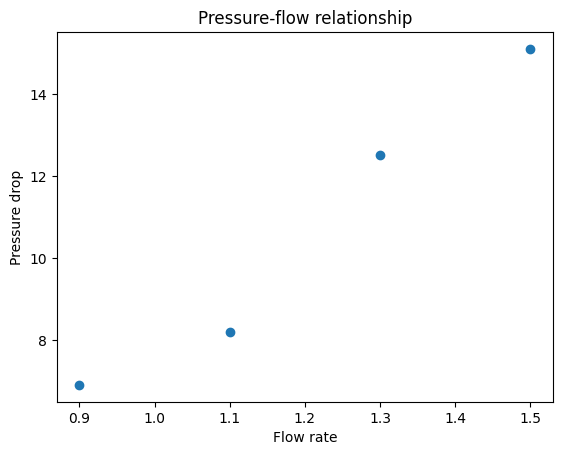

In [6]:
plt.figure()
plt.scatter(data["flow_rate"], data["pressure_drop"])
plt.xlabel("Flow rate")
plt.ylabel("Pressure drop")
plt.title("Pressure-flow relationship")
plt.show()

### Your turn

Add a new row to the dataset with your own `case_id`, `pressure_drop`, and `flow_rate`. Recompute the `resistance_index` column and regenerate the plot.

## Computational cost and scaling

We can measure how long a calculation takes as the input size grows. Matrix inversion is a common example, and its cost grows quickly with size (roughly $O(n^3)$).

In [37]:
import time

def time_matrix_inversion(n, repeats=3, seed=0):
    rng = np.random.default_rng(seed)
    # Add a small identity term to reduce the chance of a singular matrix.
    a = rng.random((n, n)) + np.eye(n) * 1e-3
    durations = []
    for _ in range(repeats):
        start = time.perf_counter()
        np.linalg.inv(a)
        durations.append(time.perf_counter() - start)
    return min(durations)

sizes = [50, 100, 150, 200, 250, 300]
print("Matrix sizes:", sizes)
times = [time_matrix_inversion(n) for n in sizes]
print("Times:")
times

Matrix sizes: [50, 100, 150, 200, 250, 300]
Times:


[0.00013587498688139021,
 0.0002658329904079437,
 0.0004621660045813769,
 0.0006039169966243207,
 0.0008684170024935156,
 0.001340040995273739]

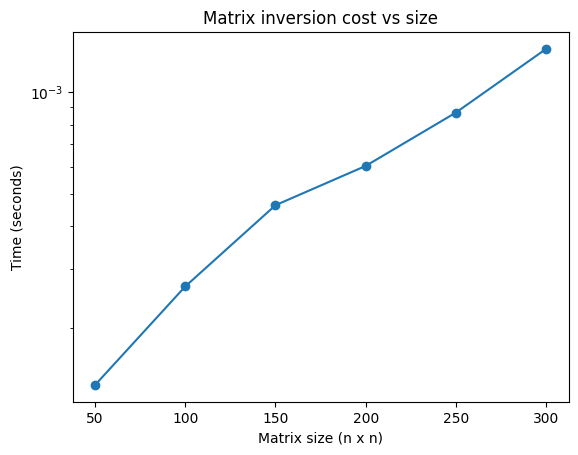

In [38]:
plt.figure()
plt.plot(sizes, times, marker="o")
plt.xlabel("Matrix size (n x n)")
plt.ylabel("Time (seconds)")
plt.title("Matrix inversion cost vs size")
plt.yscale("log")
plt.show()

In [41]:
import time

def time_matrix_inversion(n, repeats=3, seed=0):
    rng = np.random.default_rng(seed)
    # Add a small identity term to reduce the chance of a singular matrix.
    a = rng.random((n, n)) + np.eye(n) * 1e-3
    durations = []
    for _ in range(repeats):
        start = time.perf_counter()
        np.linalg.inv(a)
        durations.append(time.perf_counter() - start)
    return min(durations)

sizes = [5, 50, 500, 5000]
print("Matrix sizes:", sizes)
times = [time_matrix_inversion(n) for n in sizes]
print("Times:")
times

Matrix sizes: [5, 50, 500, 5000]
Times:


[7.499998901039362e-06,
 7.904201629571617e-05,
 0.003368375007994473,
 0.8566970000101719]

### Your turn

1. duplicate the above two code cells (the one that defines `sizes` and the one that plots the inversion time).
2. Replace the `sizes` list with your own values, for example: `sizes = [100, 200, 300, 400, 500]`.
3. Run.

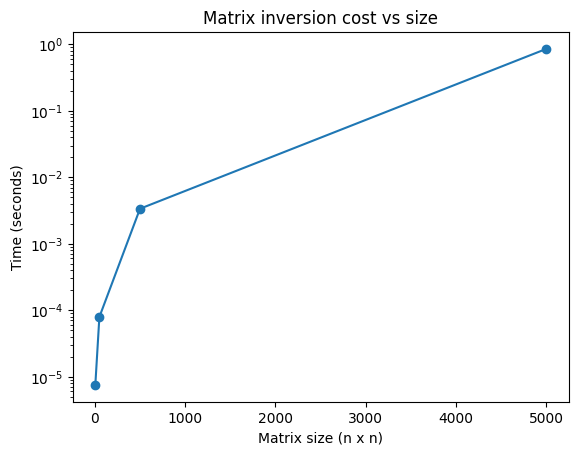

In [42]:
plt.figure()
plt.plot(sizes, times, marker="o")
plt.xlabel("Matrix size (n x n)")
plt.ylabel("Time (seconds)")
plt.title("Matrix inversion cost vs size")
plt.yscale("log")
plt.show()

## System resources and parallelization

Before deciding how to speed things up, check what CPU and GPU resources you have available.

In [44]:
import os
import platform
import shutil
import subprocess
import sys

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("OS:", platform.platform())
print("CPU cores:", os.cpu_count())

gpu_info = "No GPU detected"
try:
    import torch

    if torch.cuda.is_available():
        gpu_info = torch.cuda.get_device_name(0)
except Exception:
    pass

if gpu_info == "No GPU detected" and shutil.which("nvidia-smi"):
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=False,
    )
    if result.returncode == 0 and result.stdout.strip():
        gpu_info = result.stdout.strip().splitlines()[0]

print("GPU:", gpu_info)

config = np.__config__
get_info = getattr(config, "get_info", None)
if callable(get_info):
    blas_info = get_info("blas_opt_info")
    print("BLAS:", blas_info.get("libraries", "unknown"))
else:
    print("BLAS: unknown (NumPy config API not available)")

Python: 3.13.5
NumPy: 2.3.3
OS: macOS-26.4.1-arm64-arm-64bit-Mach-O
CPU cores: 14
GPU: No GPU detected
BLAS: unknown (NumPy config API not available)


### Where parallelization helps

- For a single matrix inversion, optimized numerical libraries already use CPU threads under the hood.
- For many independent inversions, you can parallelize across CPU cores or offload to a GPU (if available).
- Thread settings like `OMP_NUM_THREADS` or `MKL_NUM_THREADS` must be set *before* importing NumPy.

### Optional: GPU acceleration (if available)

If a CUDA GPU is available, the next cell times a small inversion on the GPU. If not, it prints a message and skips.

In [ ]:
import time

try:
    import torch
except Exception as exc:
    print("PyTorch not available:", exc)
else:
    if not torch.cuda.is_available():
        print("CUDA GPU not available. Skipping GPU timing.")
    else:
        device = "cuda"
        n = 512
        torch.manual_seed(0)
        a = torch.rand((n, n), device=device) + torch.eye(n, device=device) * 1e-3

        # Warm-up and synchronize before timing.
        torch.linalg.inv(a)
        torch.cuda.synchronize()

        start = time.perf_counter()
        torch.linalg.inv(a)
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

        print("GPU:", torch.cuda.get_device_name(0))
        print("GPU inversion time (s):", round(elapsed, 3), "for n=", n)

In [45]:
thread_env = {
    "OMP_NUM_THREADS": os.environ.get("OMP_NUM_THREADS"),
    "MKL_NUM_THREADS": os.environ.get("MKL_NUM_THREADS"),
    "OPENBLAS_NUM_THREADS": os.environ.get("OPENBLAS_NUM_THREADS"),
}
thread_env

{'OMP_NUM_THREADS': None,
 'MKL_NUM_THREADS': None,
 'OPENBLAS_NUM_THREADS': None}

### Optional: parallelize many independent inversions

In notebooks, process-based parallelism can require extra setup, so we use threads here to demonstrate the idea. For CPU-bound work, threads may not be faster, but the workflow is the same.

In [58]:
from concurrent.futures import ThreadPoolExecutor

def invert_and_time(n, seed):
    rng = np.random.default_rng(seed)
    a = rng.random((n, n)) + np.eye(n) * 1e-3
    start = time.perf_counter()
    np.linalg.inv(a)
    return time.perf_counter() - start

batch_sizes = [2000, 2000, 2000, 2000, 2000, 2000, 2000]
seeds = list(range(len(batch_sizes)))

print("Batch sizes:", batch_sizes)
print("Seeds:", seeds)

start = time.perf_counter()
seq_times = [invert_and_time(n, s) for n, s in zip(batch_sizes, seeds)]
seq_total = time.perf_counter() - start

max_workers = min(4, os.cpu_count() or 1)
start = time.perf_counter()
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    par_times = list(executor.map(invert_and_time, batch_sizes, seeds))
par_total = time.perf_counter() - start

print("Sequential CPU total (s):", round(seq_total, 3))
print("Parallel CPU total (s):", round(par_total, 3))
print("Workers:", max_workers)

Batch sizes: [2000, 2000, 2000, 2000, 2000, 2000, 2000]
Seeds: [0, 1, 2, 3, 4, 5, 6]
Sequential CPU total (s): 0.517
Parallel CPU total (s): 0.297
Workers: 4


## Wrap-up

Before the next session, make sure you can explain the key terms from this notebook in your own words and repeat the hands-on exercise without copying every command.